In [1]:
import cv2
import numpy as np
import random
import math
from matplotlib import pyplot as plt

random.seed(42)

# SYSTEM PARAMETERS

You are free to change the value of these variables for testing, but do not add extra variables here. This entire block will be replaced when marking.

In [2]:
# DO NOT ADD OTHER VARIABLES HERE

# General settings
seed = 4269
image_file = "sample_map.png"

# Task 1 - Occupancy map
unsafe_kernel_size = 7
unsafe_iterations = 3

# Task 3 - BFS
bfs_n = 12
bfs_start_node = 0
bfs_end_node = 143

# Task 4 - PRM and Dijkstra
prm_total_nodes_count = 69
prm_connection_radius = 200
prm_start_location = (40,40)
prm_goal_location = (450,450)

# Task 5 - RRT
rrt_max_nodes_count = 500
rrt_step_size = 40
rrt_max_connection_length = 200
rrt_start_location = (40,40)
rrt_goal_location = (450,450)

# DO NOT ADD OTHER VARIABLES HERE

# Task 1 - OCCUPANCY MAP (5 marks total)

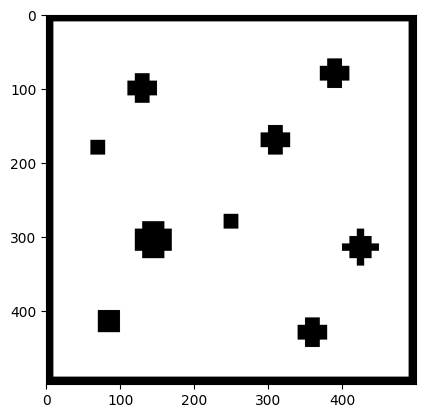

In [3]:
# Task 1.1 (1 mark): Display the occupancy map
image = cv2.imread(image_file)

# Display resulting image
plt.imshow(image)
plt.show()


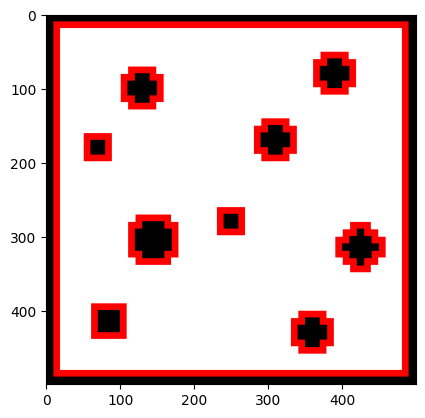

In [4]:
# Task 1.2 (4 Marks): Process occupancy map add and display configuration space
kernel = np.ones((unsafe_kernel_size, unsafe_kernel_size), np.uint8) # TODO: Use this kernenl to generate un_safe area
erosion = cv2.erode(image, kernel, iterations = unsafe_iterations)

mask = cv2.bitwise_xor(image, erosion)
red_mask = np.zeros_like(image)
red_mask[:, :] = [0, 0, 255]
red_area = cv2.bitwise_and(red_mask, mask)

output = cv2.add(erosion, red_area)

# Display resulting image
occ_map = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
plt.imshow(occ_map)
plt.show()

# Task 2 - Graph Class (0 marks total)

NOTE: This is slightly different to the graph in lab 07. x,y variables have been added to the node object.

In [5]:
# Task 2.1 (0 marks):  Complete the graph class

class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        if node_id not in self.nodes:
            self.nodes[node_id] = Node(node_id, x, y)
            self.edges[node_id] = {}

    def add_edge(self, node_id1, node_id2, weight):
        self.edges[node_id1][node_id2] = weight
        self.edges[node_id2][node_id1] = weight
        
    def remove_edge(self, node_id1, node_id2):
        self.edges[node_id1].pop(node_id2)
        self.edges[node_id2].pop(node_id1)
    
    def get_nodes(self):
        nodes = []
        for key, val in self.nodes.items():
            nodes.append(Node(key))
        return nodes
    
    def get_edge_weight(self, node_id1, node_id2):
        return self.edges[node_id1][node_id2]


# Task 3 - BFS (10 marks total)

In [6]:
# This is a useful function that you may choose to implement and use 
# It looks through the image to see if the path is clear between one coordinate to the next
# Returns True or False 
def path_clear(image, x1, y1, x2, y2):
    temp = image.copy()
    cv2.line(temp, (x1, y1), (x2, y2), (255, 255, 255), 1)
    difference = cv2.bitwise_xor(temp, image)
    return np.count_nonzero(difference) == 0

def draw_nodes_and_edges(image, graph):
    for node1, nbrs in graph.edges.items():
        for node2 in nbrs:
            (x1,y1) = graph.nodes[node1].get_point()
            (x2,y2) = graph.nodes[node2].get_point()
            cv2.circle(image, (x1, y1), 3, (0, 255, 0), -1)
            cv2.line(image, (x1, y1), (x2, y2), (0, 125, 0), 1)
#             cv2.putText(image, str(node1), (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
def draw_blue_path(image, graph, path):
    # Draw path
    for i, node in enumerate(path):
        if i == (len(path) - 1):
            break

        next_node = path[i + 1]
        (x1,y1) = graph.nodes[node].get_point()
        (x2,y2) = graph.nodes[next_node].get_point()
        cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 3)

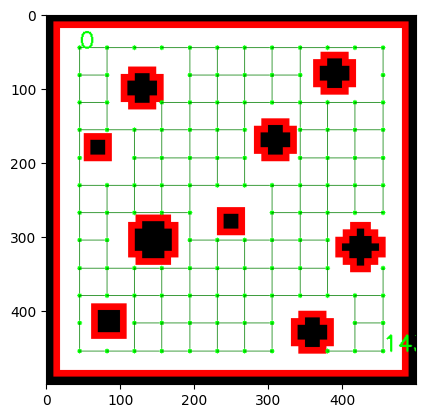

In [7]:
# Task 3.1 (5 marks): Generate a grid of nodes and connect the edges
bfs_image = occ_map.copy()
bfs_graph = Graph()

# pixel coordinates of each node
h, w = bfs_image.shape[0:2]
xs = np.linspace(45, w-45, bfs_n, dtype=int)
ys = np.linspace(45, h-45, bfs_n, dtype=int)

bfs_pos = []
for y in ys:
    for x in xs:
        bfs_pos.append((x, y))


# add nodes into bfs_graph
for i, (x, y) in enumerate(bfs_pos):
    bfs_graph.add_node(i, x, y)
    

# add edges into bfs_graph
for i, (x, y) in enumerate(bfs_pos):
    # check right node
    next_node = i + 1
    if (i % bfs_n != (bfs_n - 1)):
        (x2, y2) = bfs_pos[next_node] # node on the right
        is_clear = path_clear(occ_map, x, y, x2, y2)
        if is_clear is True:
            bfs_graph.add_edge(i, i + 1, 1)
    
    # check down node
    next_node = i + bfs_n
    if next_node > (bfs_n * bfs_n - 1):
        continue
    (x2, y2) = bfs_pos[next_node] # node directly below
    is_clear = path_clear(occ_map, x, y, x2, y2)
    if is_clear is True:
        bfs_graph.add_edge(i, i + bfs_n, 1)


# Display the image
draw_nodes_and_edges(bfs_image, bfs_graph)

# Label first and last positions
x_first, y_first = bfs_pos[0]
x_last, y_last = bfs_pos[-1]
last_num = bfs_n * bfs_n - 1
cv2.putText(bfs_image, '0', (x_first, y_first), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
cv2.putText(bfs_image, str(last_num), (x_last, y_last), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

plt.imshow(bfs_image)
plt.show()

In [8]:
# Task 3.2 (5 marks): Implement BFS

# Returns an array of nodes in order of which nodes are visited next.
# ie. [0, 10, 20, 30, 40, 50, 60, 70, 71, 72, 73, 74, 75, 76, 77, 78, 88, 98, 99]
def bfs(graph, start_node_id, end_node_id):
    q = []
    cost = [-1] * len(graph.nodes)
    parent = [-1] * len(graph.nodes)
    
    # insert start node as visited
    q.append(start_node_id)
    cost[start_node_id] = 0
    
    # run search
    while len(q) != 0:
        x = q.pop(0)
        
        if x == end_node_id:
            break
        
        for nbr in graph.edges[x]:
            if cost[nbr] == -1:
                cost[nbr] = cost[x] + 1
                q.append(nbr)
                parent[nbr] = x
    
    # check if end is reachable
    if cost[end_node_id] == -1:
        print(f"No path between node {start_node_id} and node {end_node_id}")
        return
    
    # obtain path
    path = []
    i = end_node_id
    while i != -1:
        path.append(i)
        i = parent[i]

    path.reverse()
    return path

Path: [0, 1, 2, 3, 4, 5, 6, 7, 8, 20, 32, 33, 45, 57, 69, 81, 93, 105, 117, 118, 119, 131, 143]


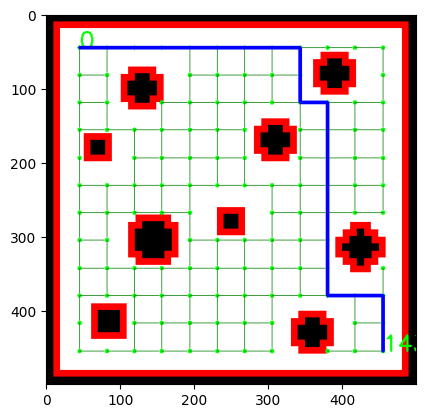

In [9]:
# Task 3.2: Implement BFS continued

# Run BFS and display the output
path = bfs(bfs_graph,bfs_start_node,bfs_end_node)

# Display the resulting image
print(f"Path: {path}")

# Draw path
draw_blue_path(bfs_image, bfs_graph, path)

plt.imshow(bfs_image)
plt.show()

# Task 4 -  PRM and Dijkstra Algorithm (6 marks total)

In [10]:
# This is a useful function that you may choose to implement and use 
# It finds and returns the closest nodes that are within the range
def find_closest_nodes(image,graph, target_x, target_y,range):

    distances = []

    return distances[:n]

def in_free_space(image, x, y):
    temp = image.copy()
    cv2.circle(temp, (x, y), 0, (255, 255, 255), -1)
    difference = cv2.bitwise_xor(temp, image)
    return np.count_nonzero(difference) == 0

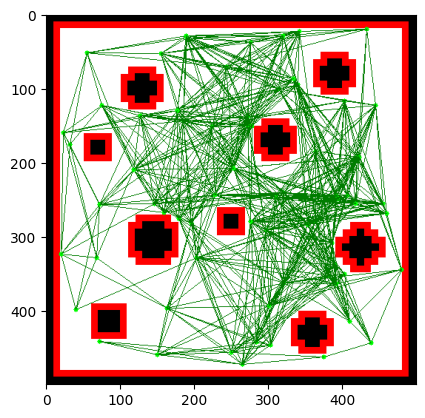

In [11]:
# Task 4.1 (3 marks): PRM
# NOTE: The iteration only increases when a valid node is placed on the map. If the node is invalid, the program should continue without incrementing the node count. 

prm_image = occ_map.copy()
prm_graph = Graph()
random.seed(seed)

i = 0

# Generate random nodes
prm_pos = []
while i < prm_total_nodes_count:
    y = random.randint(0, prm_image.shape[0]-1)
    x = random.randint(0, prm_image.shape[1]-1)
    
    # Check if node is in free space
    if path_clear(prm_image, x, y, x, y) is True:
        prm_pos.append((x, y))
        i += 1
    
# Add nodes
for i, (x, y) in enumerate(prm_pos):
    prm_graph.add_node(i, x, y)

# Add edges
for i, (x1, y1) in enumerate(prm_pos):
    for j, (x2, y2) in enumerate(prm_pos):
        if i == j:
            continue
        
        # Check if nodes is within radius
        dist = math.sqrt((x2 - x1) ** 2  + (y2 - y1) ** 2)
        if dist > prm_connection_radius:
            continue
            
        # Add edge if  path is clear
        is_clear = path_clear(occ_map, x1, y1, x2, y2)
        if is_clear is True:
            prm_graph.add_edge(i, j, dist)

draw_nodes_and_edges(prm_image, prm_graph)

# Display the resulting image
plt.imshow(prm_image)
plt.show()

In [12]:
# Task 4.2 (3 marks): Dijkstra
# Example output - Path: [-1, 143, 43, 1, 14, 44, 67, 7, 9, 4, 12, 364, -2], Cost: 561.9189671797234
def dijkstra(graph, start_id, end_id):    
    n = len(graph.nodes)
    p_q = []
    cost = [-1] * n
    parent = [-1] * n
    # Set start_id and end_id as positive (last two indexes of list)
    start = n + start_id
    end = n + end_id
    
    # Insert start node as visited
    p_q.append(start)
    cost[start] = 0
    
    # Run search
    while len(p_q) != 0:
        p_q.sort(key = lambda a : cost[a])
        x = p_q.pop(0)
        
        if x == end_id:
            break
        
        temp = x
        # Change index back to original negative index
        if temp == start:
            temp = -1
        elif temp == end:
            temp = -2
        
        for nbr, w in graph.edges[temp].items():
            
            if nbr == -1:
                nbr = start
            elif nbr == -2:
                nbr = end
            
            new_cost = cost[temp] + w
            if cost[nbr] == -1:
                cost[nbr] = new_cost
                parent[nbr] = x
                p_q.append(nbr)
            elif new_cost < cost[nbr]:
                cost[nbr] = new_cost
                parent[nbr] = x
                p_q.append(nbr)
        
                
    # Check if end is reachable
    if cost[end] == -1:
        print(f"No path between node {start_id} and node {end_id}")
        return (0, 0)
    
    # Obtain path and cost
    total_cost = cost[end]
    path = []
    i = end
    while i != -1:
        temp = i
        if temp == start:
            temp = -1
        elif temp == end:
            temp = -2

        path.append(temp)
        i = parent[i]    

    path.reverse()
    return (path, total_cost)

In [ ]:
# Task 4.2: Dijkstra continued

# Add start (node id = -1) and end (node_id = -2 ) nodes
start_x, start_y = prm_start_location
goal_x, goal_y = prm_goal_location
prm_graph.add_node(-2, goal_x, goal_y) # end node
prm_graph.add_node(-1, start_x, start_y) # start node

# Add edges near start and end nodes
for i, (x1, y1) in enumerate(prm_pos):
    # Check if nodes is within radius of start node
    dist = math.sqrt((start_x - x1) ** 2  + (start_y - y1) ** 2)
    if dist <= prm_connection_radius:
        # Add edge if path is clear
        is_clear = path_clear(occ_map, x1, y1, start_x, start_y)
        if is_clear is True:
            prm_graph.add_edge(-1, i, dist)
        
    # Check nearby nodes of end node
    dist = math.sqrt((goal_x - x1) ** 2  + (goal_y - y1) ** 2)
    if dist > prm_connection_radius:
        continue
    
    is_clear = path_clear(occ_map, x1, y1, goal_x, goal_y)
    if is_clear is True:
        prm_graph.add_edge(-2, i, dist)

# Find path
prm_path, prm_cost = dijkstra(prm_graph, -1, -2)

# Draw path
draw_nodes_and_edges(prm_image, prm_graph)
draw_blue_path(prm_image, prm_graph, prm_path)

# Display the resulting image
print(f"Path: {prm_path}, Cost: {prm_cost}")
plt.imshow(prm_image)
plt.show()


IndexError: list assignment index out of range

# Task 5 - Rapidly-exploring random trees (RRT) (4 marks total)

In [14]:
# This is a useful function which you may choose to impliment and use 
# Given a random point it extends the tree by either the step distance or the cartesian distance
def calculate_new_tree_point(near_x, near_y, target_x, target_y, step):
    dist = math.sqrt((target_x - near_x) ** 2 + (target_y - near_y) ** 2)
    if dist == 0:
        return near_x, near_y, 0
    
    x = near_x + step * (target_x - near_x) / dist
    y = near_y + step * (target_y - near_y) / dist
    return x, y, step
    

# This is a useful function which you may choose to impliment and use 
# It finds and returns the closest node to a point on the image
def find_closest_node_rrt(graph, target_x, target_y):
    close_x, close_y = (0, 0)
    node_id = 0
    min_dist = math.inf
    for node in graph.nodes.values():
        x, y = node.get_point()
        dist = math.sqrt((target_x - x) ** 2  + (target_y - y) ** 2)
        if dist < min_dist:
            min_dist = dist
            node_id = node.get_ID()
            close_x, close_y = (x, y)

    return close_x, close_y, node_id

def add_and_rewire(new_n, new_x, new_y, near_n, new_d):
    rrt_graph.add_node(new_n, new_x, new_y)
    
    nbrs = []
    for n_i, node in rrt_graph.nodes.items():
        if n_i == new_n:
            continue
        n_x, n_y = node.get_point()
        dist = math.sqrt((n_x - new_x) ** 2  + (n_y - new_y) ** 2)
        if dist < rrt_max_connection_length and \
        path_clear(rrt_image, round(n_x), round(n_y), round(new_x), round(new_y)):
            nbrs.append((n_i, dist))
    
    # Choose best node in neighbours (lowest cost)
    best_n = near_n
    best_cost = cost[near_n] + new_d
    for n_i, d in nbrs:
        c = cost[n_i] + d
        if c < best_cost:
            best_cost = c
            best_n = n_i
    
    # Add the best node edge
    rrt_graph.add_edge(best_n, new_n, best_cost - cost[best_n])
    cost[new_n] = best_cost
    rrt_parent[new_n] = best_n

Final iteration count: 86
Path: [-1, 0, 2, 11, 29, 81, 85, -2], Cost: 601.7095700801029


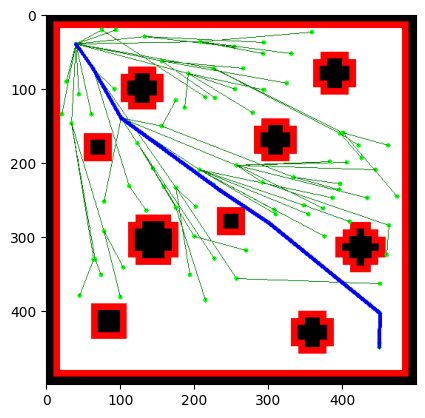

In [15]:
# Task 5.1 (4 marks): RRT/RRT*
# NOTE: The iteration only increases when a valid node is placed on the map. If the node is invalid, the program should continue without incrementing the node count. 

rrt_image = occ_map.copy()
rrt_graph = Graph()
random.seed(seed)

# Generate the start node with a node ID of -1
start_x, start_y = rrt_start_location
rrt_graph.add_node(-1, start_x, start_y) # start node

# Generate the RRT
goal_x, goal_y = rrt_goal_location

cost = {-1: 0}
rrt_parent = {-1 : None}

rrt_beta = 0.2
i = 0
goal_connected = False
while i < rrt_max_nodes_count:
    # Generate random target node
    tar_x = random.randint(0, rrt_image.shape[0]-1)
    tar_y = random.randint(0, rrt_image.shape[1]-1)
    
    # Check if target node is in free space
    if path_clear(rrt_image, tar_x, tar_y, tar_x, tar_y) is False:
        continue

    # Occasionally set goal node as target node
    if random.random() < rrt_beta:
        tar_x, tar_y = rrt_goal_location
        
    # Find nearest existing node to target node
    near_x, near_y, near_n = find_closest_node_rrt(rrt_graph, tar_x, tar_y)

    # Check if goal node is close enough to nearest node
    dist = math.sqrt((near_x - goal_x) ** 2  + (near_y - goal_y) ** 2)
    if dist < rrt_step_size:
        # RRT*
        add_and_rewire(-2, goal_x, goal_y, near_n, dist)
        
        # Solution found
        goal_connected = True
        print(f"Final iteration count: {i}")
        break
    else:
        # Generate new node from nearest node towards target node
        new_x, new_y, new_d = calculate_new_tree_point(near_x, near_y, tar_x, tar_y, rrt_step_size)

        # Check if new node is in free space
        if path_clear(rrt_image, round(new_x), round(new_y), round(new_x), round(new_y)) is False:
            continue

        # Check if path is clear between new and near
        if path_clear(rrt_image, round(near_x), round(near_y), round(new_x), round(new_y)) is False:
            continue 

        # RRT*
        add_and_rewire(i, round(new_x), round(new_y), near_n, new_d)
        
    i += 1

# Path Find and show resulting image
if goal_connected is True:
    rrt_path, rrt_cost = dijkstra(rrt_graph, -1, -2)
    
    draw_nodes_and_edges(rrt_image, rrt_graph)
    draw_blue_path(rrt_image, rrt_graph, rrt_path)

    print(f"Path: {rrt_path}, Cost: {rrt_cost}")
    plt.imshow(rrt_image)
    plt.show()
else:
    print("No Valid Path/Not enough nodes!")
    draw_nodes_and_edges(rrt_image, rrt_graph)
    plt.imshow(rrt_image)
    plt.show()

In [16]:
#     if i == 12:
#         print(f"Cost: {cost}")
#         x, y = rrt_graph.nodes[i].get_point()
#         print(f"Node {i}: ({x}, {y})")
#         print(f"Node {i}'s parent is {rrt_parent[i]}")
#         min_dist = math.sqrt((x - 50) ** 2 + (y - 50) ** 2)
#         print(f"Theoretical minimum distance is {min_dist}. Current distance is {cost[i]}")
#         test_img = rrt_image.copy()
#         draw_nodes_and_edges(test_img, rrt_graph)
#         cv2.circle(test_img, (tar_x, tar_y), 3, (255, 0, 255), -1)
        
#         plt.imshow(test_img)
#         plt.title(f"Iteration {i}")
#         plt.show()

In [18]:
print(bfs_pos[0])
tlx, tly = bfs_pos[0]
print(tlx)

(np.int64(45), np.int64(45))
45
